# Embeddings in Recommender Systems

In this notebook, we'll explore **embeddings** - a powerful technique for creating compact, meaningful representations of users and items. Think of embeddings as a way to compress the sparse, high-dimensional data we work with in recommender systems into dense, lower-dimensional vectors that capture the essential patterns.

## Why Embeddings Matter

Recall from the essentials course that we work with large, sparse matrices:
- **User-item rating matrix**: Most entries are missing (users don't rate most items)
- **Item feature matrices**: High-dimensional and sparse (most features don't apply to most items)

**Real-world scale challenge:**
- Netflix: ~250M users × ~15K titles = 3.75 trillion potential ratings
- Spotify: ~400M users × ~80M songs = 32 quadrillion potential interactions

Even sparse representations become unfeasible to scale. Embeddings solve this issue by learning compact representations that capture the most important patterns.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

# For neural network embeddings
import torch
import torch.nn as nn

%matplotlib inline
plt.style.use('default')
sns.set_palette("husl")

# Matrix Factorization: The Core of Embeddings

**Matrix Factorization** is the fundamental technique behind most embedding approaches in recommender systems. The idea is simple yet powerful:

> Instead of storing a large sparse matrix R, we approximate it as the product of two smaller dense matrices

$$R \approx P \times Q^T$$

Where:
- **P**: User embeddings (users × factors) - captures user preferences in latent space
- **Q**: Item embeddings (items × factors) - captures item characteristics in latent space
- **factors**: The embedding dimension (typically 50-200)

## Why This Works

Each user and item gets represented as a dense vector in the same latent space. The dot product of these vectors predicts the user's rating for that item:

$$\hat{r}_{ui} = p_u \cdot q_i$$

This means similar users have similar embeddings, and similar items have similar embeddings!

# Loading Our Data

Let's use the same MovieLens dataset from the essentials course to see matrix factorization in action.

In [2]:
# Load MovieLens data
data_path = "../data/ml-latest-small"

# Load ratings and movies
ratings = pd.read_csv(os.path.join(data_path, "ratings.csv"))
movies = pd.read_csv(os.path.join(data_path, "movies.csv"))

print("Dataset info:")
print(f"- {ratings['userId'].nunique()} users")
print(f"- {ratings['movieId'].nunique()} movies")
print(f"- {len(ratings)} ratings")
print(
    f"- Sparsity: {100 * (1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())):.1f}%")

ratings.head()

Dataset info:
- 671 users
- 9066 movies
- 100004 ratings
- Sparsity: 98.4%


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


# Method 1: Singular Value Decomposition (SVD)

We’ll start with a rudimentary, non-learning technique named **Singular Value Decomposition**, by using `sklearn.decomposition.TruncatedSVD`. This directly factorizes a user–item matrix without fitting a predictive model.

Why use **SVD** here?
- Simple and fast baseline to illustrate dimensionality reduction
- Lets us visualize how number of factors (embedding vector dimension) impacts the amount of information we can compress
- No explicit rating prediction objective; purely decomposition-based

SVD is a mathematical technique that decomposes a matrix $R$ into three smaller matrices, $U$, $\Sigma$, and $V^T$, such that:

$$ R \approx U \Sigma V^T $$

Where:
- $U$ contains the left singular vectors (user features)
- $\Sigma$ is a diagonal matrix of singular values (importance of each feature)
- $V^T$ contains the right singular vectors (item features)

So, a matrix of dimensions $m \times n$ (users × items) can be approximated by:

$$ R \approx U_{m \times k} \Sigma_{k \times k} V^T_{k \times n} $$

Where $k$ is the number of latent factors, the dimensions of the embedding space. 
So, we can choose $k$ based on the desired level of compression and the amount of information we want to retain.
We typically call this *explained variance*, which quantifies how much information (variance) is retained in the reduced representation compared to the original data.
Obviously, the larger $k$ is, the more information we can retain, but we'll be reducing the compression ratio. 
The idea is to find a sweet spot of $k$ that balances these trade-offs.

Scikit-learn's `TruncatedSVD` allows us to do exactly that: factorize matrix $R$ and get the user and item embeddings with a fixed dimension $k$, by selecting the $k$ factors with the largest singular value, which roughly translates to the most information-dense features.


In [10]:
n_factors = 64 # k, the dimension of the resulting embedding vectors
random_state = 42

In [ ]:
# Build a (sparse) user–item rating matrix
ui = ratings.pivot_table(index='userId', columns='movieId',
                         values='rating', aggfunc='mean').fillna(0.0)
print(f"User–Item matrix: {ui.shape} (users x items)")

# Choose embedding dimension (number of factors)
svd = TruncatedSVD(n_components=n_factors, random_state=random_state)
user_embeddings_svd = svd.fit_transform(ui.values)		# shape: (n_users, n_factors)

item_embeddings_svd = svd.components_.T					# shape: (n_items, n_factors)

print("\nEmbeddings (TruncatedSVD):")
print(f"- User embeddings: {user_embeddings_svd.shape}")
print(f"- Item embeddings: {item_embeddings_svd.shape}")

# Compression intuition
original = ui.shape[0] * ui.shape[1]
compressed = user_embeddings_svd.size + item_embeddings_svd.size
print("\nCompression:")
print(f"- Original elements: {original:,}")
print(f"- Compressed elements: {compressed:,}")
print(
    f"- Ratio: {original/compressed if (compressed>0) else float('inf'):.2f}x")



User–Item matrix: (671, 9066) (users x items)

Embeddings (TruncatedSVD):
- User embeddings: (671, 64)
- Item embeddings: (9066, 64)

Compression:
- Original elements: 6,083,286
- Compressed elements: 623,168
- Ratio: 9.76x


As you can see here, by factorizing the ratings matrix, we went from a matrix with $n \times m$ (users × items) parameters to two matrices of size $n \times k$ (user embeddings) and $k \times m$ (item embeddings), where $k$ is the number of latent factors. 
In our specific case, that's almost a $10\times$ compression!

If we think of a real scenario where 10 million users rate 2000 items... that's 20 **trillion** ($10^{12}$) parameters in the original matrix vs. ~ 1.2 billion ($10^9$) parameters in a factorized representation with $k = 128$, an incredible downsize!

However, this compression comes at a cost: some information is lost in the process. The explained variance tells us how much of the original data's variability is retained in the reduced representation. By examining the explained variance, we can better understand the trade-offs involved in choosing the number of latent factors $k$.



Explained variance (first 64 components): 0.561


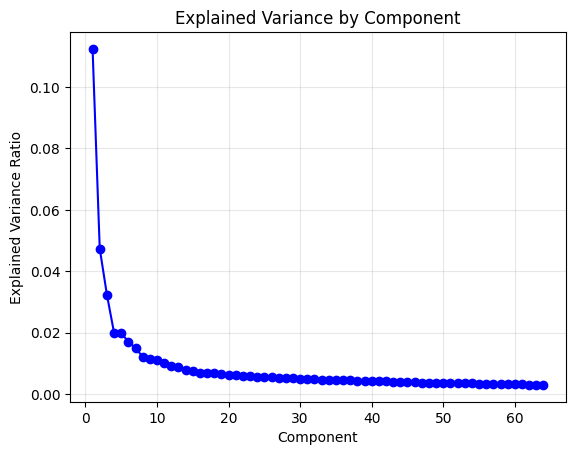

In [12]:
# Explained variance
cum_var = np.cumsum(svd.explained_variance_ratio_)
print(f"\nExplained variance (first {n_factors} components): {cum_var[-1]:.3f}")

# Plot per-component and cumulative explained variance

plt.plot(range(1, n_factors+1), svd.explained_variance_ratio_, 'bo-')
plt.title('Explained Variance by Component')
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True, alpha=0.3)

plt.show()

The explained variance ratio indicates the proportion of the dataset's variance that is captured by each component we keep in the reduced representation. With it being a ratio, the maximum is 1.0 (or 100%), which lets us know that $k = 64$ retains around $56\%$ of the Rating Matrix's information. Try playing around with the value of $k$ to see how it impacts the explained variance and the amount of compression.

# Method 2: Non-negative Matrix Factorization (NMF)

**NMF** is another popular matrix factorization technique that's particularly good for:
- Large-scale datasets (scales well)
- Implicit feedback data (views, clicks, purchases)
- Parallel processing

NMF optimizes the user and item embeddings simultaneously, enforcing non-negativity constraints. 
This often leads to more interpretable embeddings, as negative values can be hard to interpret in the context of user preferences and item characteristics. 
Besides, NMF is a learning-based technique, applying gradient descent to minimize the reconstruction error between the original matrix and the product of the user and item embeddings.
As such, it is a more complex approach compared to SVD, but it has potential to yield better performance, as it's more advanced than a simple linear decomposition.

More on Non-negative Matrix Factorization [on the Surprise package documentation](https://surprise.readthedocs.io/en/stable/matrix_factorization.html#surprise.prediction_algorithms.matrix_factorization.NMF).

In [15]:
# Use NMF (Non-negative Matrix Factorization) from Surprise
from surprise import Dataset, Reader, NMF
from surprise.model_selection import train_test_split
from surprise import accuracy

# Prepare data for Surprise without relying on prior cells
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train NMF model (NMF uses alternating updates)
nmf_model = NMF(n_factors=n_factors, random_state=random_state)
nmf_model.fit(trainset)

# Test the model
predictions_nmf = nmf_model.test(testset)
rmse_nmf = accuracy.rmse(predictions_nmf, verbose=False)

print("NMF Model Performance:")
print(f"- RMSE: {rmse_nmf:.3f}")
print(f"- Embedding dimension: {nmf_model.n_factors}")

# Extract embeddings
user_embeddings_nmf = nmf_model.pu
item_embeddings_nmf = nmf_model.qi


NMF Model Performance:
- RMSE: 1.022
- Embedding dimension: 64


Now that we've got embeddings, let's look at some users who may have similar tastes based on their interaction history and see if their embeddings vectors are similar.

Take user 1, for example. Let's see what movies he's seen:

In [29]:
# from the ratings dataframe, check what movies user 1 has seen and rated
user_1_movies = ratings[ratings['userId'] == 1][['movieId', 'rating']].merge(movies, on='movieId')
user_1_movie_ids = user_1_movies['movieId'].tolist()
user_1_movies

,movieId,rating,title,genres,genres_list
0,31,2.5,Dangerous Minds (1995),Drama,[Drama]
1,1029,3.0,Dumbo (1941),Animation|Children|Drama|Musical,"[Animation, Children, Drama, Musical]"
2,1061,3.0,Sleepers (1996),Thriller,[Thriller]
3,1129,2.0,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller,"[Action, Adventure, Sci-Fi, Thriller]"
4,1172,4.0,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,[Drama]
5,1263,2.0,"Deer Hunter, The (1978)",Drama|War,"[Drama, War]"
6,1287,2.0,Ben-Hur (1959),Action|Adventure|Drama,"[Action, Adventure, Drama]"
7,1293,2.0,Gandhi (1982),Drama,[Drama]
8,1339,3.5,Dracula (Bram Stoker's Dracula) (1992),Fantasy|Horror|Romance|Thriller,"[Fantasy, Horror, Romance, Thriller]"
9,1343,2.0,Cape Fear (1991),Thriller,[Thriller]


Let's now look at (totally randomly selected) users 634 and 566, and compare the movies they've seen with the ones User 1 has.

In [41]:
# get movie ids for users 634 and 566
user_634_movies = ratings[ratings['userId'] == 634][['movieId', 'rating']].merge(movies, on='movieId')
user_634_movie_ids = user_634_movies['movieId'].tolist()

In [33]:
user_634_movies

,movieId,rating,title,genres,genres_list
0,180,3.5,Mallrats (1995),Comedy|Romance,"[Comedy, Romance]"
1,256,1.0,Junior (1994),Comedy|Sci-Fi,"[Comedy, Sci-Fi]"
2,318,5.0,"Shawshank Redemption, The (1994)",Crime|Drama,"[Crime, Drama]"
3,355,1.5,"Flintstones, The (1994)",Children|Comedy|Fantasy,"[Children, Comedy, Fantasy]"
4,585,1.0,"Brady Bunch Movie, The (1995)",Comedy,[Comedy]
5,858,5.0,"Godfather, The (1972)",Crime|Drama,"[Crime, Drama]"
6,1129,3.0,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller,"[Action, Adventure, Sci-Fi, Thriller]"
7,1221,5.0,"Godfather: Part II, The (1974)",Crime|Drama,"[Crime, Drama]"
8,1293,3.0,Gandhi (1982),Drama,[Drama]
9,1371,3.5,Star Trek: The Motion Picture (1979),Adventure|Sci-Fi,"[Adventure, Sci-Fi]"


Users 1 and 634 definitely have rated some movies in common. Could their embeddings be similar as well? Let's find out by computing the cosine similarity between their movie embeddings.

In [39]:
# cosine similarity between the embeddings of users 1 and 634
u1_emb_svd = user_embeddings_svd[1]
u634_emb_svd = user_embeddings_svd[634]

u1_emb_nmf = user_embeddings_nmf[1]
u634_emb_nmf = user_embeddings_nmf[634]

nmf_sim = np.dot(u1_emb_nmf, u634_emb_nmf) / (
    np.linalg.norm(u1_emb_nmf) * np.linalg.norm(u634_emb_nmf)
)

svd_sim = np.dot(u1_emb_svd, u634_emb_svd) / (
    np.linalg.norm(u1_emb_svd) * np.linalg.norm(u634_emb_svd)
)

print(f"Cosine similarity between users 1 and 634 calculated via NMF: {nmf_sim}")
print(f"Cosine similarity between users 1 and 634 calculated via SVD: {svd_sim}")

Cosine similarity between users 1 and 634 calculated via NMF: 0.8264953395767086
Cosine similarity between users 1 and 634 calculated via SVD: 0.23504713850981734


As we can see, the cosine similarities calculated via NMF and SVD for users 1 and 566 are quite different. This indicates that the two embedding techniques capture different aspects of user preferences and behaviors.
However, for the more advanced NMF embeddings, the two users are considered fairly similar (reviews-wise), as their embedding vectors are close in the NMF space.

Try using a larger number of factors and see if the cosine similarity changes significantly, especially for the SVD-based embeddings.

# Context-Based Embeddings with Neural Networks

Matrix factorization is great for user-item interactions, but what about **item metadata**? What about when we have very complex, sometimes unstructured, features like text-based ones? Feature engineering each one of these features is not feasible, especially in practical systems where there can be hundreds of features each with its own nuances.

To solve this problem, we can apply the embeddings concept to features themselves. Instead of having unstructured, arbitrary features, we can encode these into a lower-dimensional space using neural networks.

If you're familiar with language-processing systems (and LLMs), that's exactly what they do — encode sequences of syllables, words, and entire sentences into fixed-size vectors. Typically, this operation is done by networks named Encoders, which take unstructured data as input and transform it into compressed, fixed-size embeddings vectors.

In our recommender systems context, we could create an Encoder network which creates embeddings for stuff like:
- Movie title and genre, tags, synopsis, participating actors and directors
- User demographics, location, device type
- Context: time of day, season, mood

Since our example is fairly simple, let's create a neural network that can generate embeddings for movie titles, genres, and tags.

In [ ]:
import re

# Building a simple text field per movie from title + genres + tags
tags = pd.read_csv(os.path.join(data_path, "tags.csv"))


def clean(s):
    # clean up the text by getting rid of special characters (non lower letter and numbers)
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9+#]+', ' ', s)			# keep only lower letters, numbers, + and #
    return re.sub(r'\s+', ' ', s).strip()		# remove extra spaces


# Aggregate tags per movie (dedupe, keep at most 30 to keep inputs small)
tags['tag_clean'] = tags['tag'].map(clean)
tags_agg = (
    tags.groupby('movieId')['tag_clean']
        .apply(lambda x: ' '.join(pd.unique([t for t in x if t])[:30]))
        .reset_index(name='tags_text')
)

# Ensure we only work on movies that appear in ratings (same as before)
movies_subset = movies[movies['movieId'].isin(ratings['movieId'])].copy()

movies_text = movies_subset.merge(tags_agg, on='movieId', how='left')
movies_text['genres_text'] = movies_text['genres'].str.replace('|', ' ', regex=False).map(clean) 	# apply the clean function to the genres
movies_text['title_text'] = movies_text['title'].map(clean)											# apply it to the titles
movies_text['tags_text'] = movies_text['tags_text'].fillna('')

# One compact text per movie
movies_text['context_text'] = (
    movies_text['title_text'] + ' genres: ' + movies_text['genres_text'] +
    ' tags: ' + movies_text['tags_text']
)

print("Example context text:\n", movies_text[['movieId', 'title','context_text']].head(3))

Example context text:
    movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        context_text  
0  toy story 1995 genres: adventure animation chi...  
1  jumanji 1995 genres: adventure children fantas...  
2  grumpier old men 1995 genres: comedy romance t...  


In [23]:
from sentence_transformers import SentenceTransformer

# Now that we've created a sentence for each movie, let's encode it to embeddings
model_name = "sentence-transformers/all-MiniLM-L6-v2"  # small, fast, 384-dim
text_model = SentenceTransformer(model_name)

movie_text_embeddings = text_model.encode(
    movies_text['context_text'].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # cosine-friendly
)

print(f"Text embeddings shape: {movie_text_embeddings.shape}")

Batches: 100%|██████████| 36/36 [00:03<00:00, 11.74it/s]

Text embeddings shape: (9066, 384)


Now, for all movies, we've created a **context** embedding, a 384-dimensional vector that captures the semantic meaning of the movie's title, genres, and tags. This allows us to compare movies based on their content rather than just user interactions.

# Visualizing Embeddings with t-SNE

**t-SNE** helps us see if our embeddings make sense by plotting them in 2D. Similar items should cluster together!

Let's visualize both types of embeddings we created:
1. **Matrix factorization embeddings** (from user-item interactions)
2. **Context-based embeddings** (from title, genre, and tag information)

What do you expect to see in the t-SNE visualizations? If we color the points by genre, do you think movies of the same genre will be close together with both embedding types?

What if we were to color the points by some user-related measure (like age, gender or geographical location)? Would we be able to see distinct clusters based on these attributes?

Embeddings for visualization:
- 8380 movies with both collaborative filtering and context embeddings


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


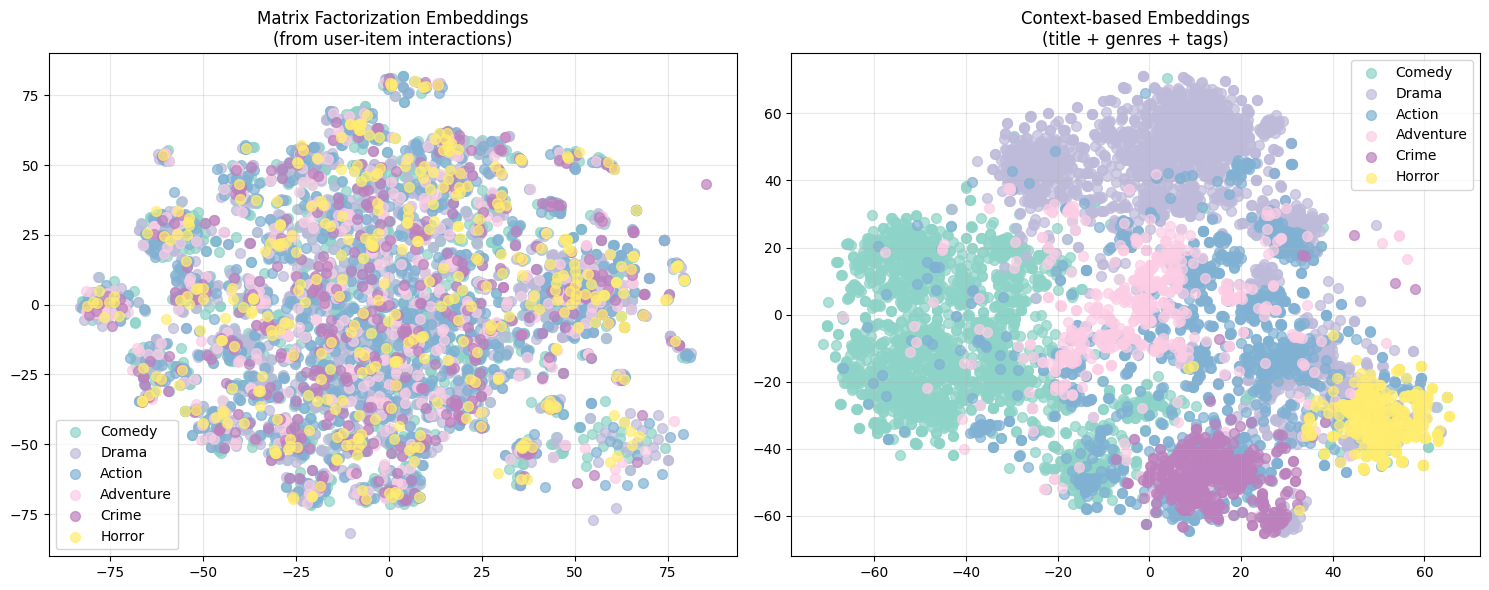


Observations:
- Do movies of similar genres cluster together?
- How do the two embedding spaces compare?
- Matrix factorization learns from user behavior
- Text embeddings use explicit title/genres/tags information


In [24]:
# Prepare data for visualization
movie_ids = movies_subset['movieId'].values
trainset_items = trainset.all_items()

# Create mapping from raw movieId (string) to Surprise internal id
movieId_to_iid = {}
for iid in trainset_items:
    movieId_to_iid[trainset.to_raw_iid(iid)] = iid  # keys are strings

# Get embeddings for movies that exist in both datasets
valid_indices = []
cf_embeddings = []
for i, movie_id in enumerate(movie_ids):
    if movie_id in movieId_to_iid:
        valid_indices.append(i)
        iid = movieId_to_iid[movie_id]
        cf_embeddings.append(item_embeddings_svd[iid])

valid_indices = np.array(valid_indices)
cf_embeddings = np.array(cf_embeddings)
context_embeddings = movie_text_embeddings[valid_indices]

print("Embeddings for visualization:")
print(f"- {len(cf_embeddings)} movies with both collaborative filtering and context embeddings")

# Apply t-SNE to both embedding types
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
cf_2d = tsne.fit_transform(cf_embeddings)

tsne2 = TSNE(n_components=2, random_state=42, perplexity=30)
context_2d = tsne2.fit_transform(context_embeddings)

# Get genre info for coloring
valid_movies = movies_text.iloc[valid_indices]  # use the text-augmented frame
valid_movies['genres_list'] = valid_movies['genres'].str.split('|')
main_genres = valid_movies['genres_list'].apply(
    lambda x: x[0] if x else 'Unknown')

# Plot both embedding spaces
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Colors for top genres
top_genres = main_genres.value_counts().head(6).index
colors = plt.cm.Set3(np.linspace(0, 1, len(top_genres)))

# Plot 1: Collaborative Filtering Embeddings
for i, genre in enumerate(top_genres):
    mask = main_genres == genre
    ax1.scatter(cf_2d[mask, 0], cf_2d[mask, 1],
                c=[colors[i]], label=genre, alpha=0.7, s=50)
ax1.set_title('Matrix Factorization Embeddings\n(from user-item interactions)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Context-based (Text) Embeddings
for i, genre in enumerate(top_genres):
    mask = main_genres == genre
    ax2.scatter(context_2d[mask, 0], context_2d[mask, 1],
                c=[colors[i]], label=genre, alpha=0.7, s=50)
ax2.set_title('Context-based Embeddings\n(title + genres + tags)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Do movies of similar genres cluster together?")
print("- How do the two embedding spaces compare?")
print("- Matrix factorization learns from user behavior")
print("- Text embeddings use explicit title/genres/tags information")

# Exploring Embedding Similarity

Let's see how embeddings capture similarity by finding movies similar to "Toy Story" using both approaches.

In [25]:
# Use the same valid_indices we built in the visualization cell
valid_movies = movies_text.iloc[valid_indices]

# Find Toy Story in our dataset
toy_story_mask = valid_movies['title'].str.contains('Toy Story', na=False)
toy_story_pos = np.where(toy_story_mask)[0][0]

# Get Toy Story embeddings
toy_story_cf = cf_embeddings[toy_story_pos].reshape(1, -1)
toy_story_context = context_embeddings[toy_story_pos].reshape(1, -1)

# Calculate similarities
cf_similarities = cosine_similarity(toy_story_cf, cf_embeddings)[0]
context_similarities = cosine_similarity(
    toy_story_context, context_embeddings)[0]

# Find top 5 most similar movies (excluding Toy Story itself)
sorted_idx = np.argsort(cf_similarities)[::-1]
cf_top5_idx = [idx for idx in sorted_idx if idx != toy_story_pos][:5]
print("\n Based on Collaborative Filtering (user behavior):")
for i, idx in enumerate(cf_top5_idx):
    movie = valid_movies.iloc[idx]
    sim = cf_similarities[idx]
    print(f"{i+1}. {movie['title']} (similarity: {sim:.3f})")

sorted_idx_context = np.argsort(context_similarities)[::-1]
context_top5_idx = [
    idx for idx in sorted_idx_context if idx != toy_story_pos][:5]
print("\n Based on Context (title + genres + tags):")
for i, idx in enumerate(context_top5_idx):
    movie = valid_movies.iloc[idx]
    sim = context_similarities[idx]
    print(f"{i+1}. {movie['title']} (similarity: {sim:.3f})")

print("\nKey Insights:")
print("- Collaborative filtering finds movies liked by similar users")
print("- Text-based context finds movies with similar descriptions/metadata")
print("- Both approaches capture different types of similarity!")


 Based on Collaborative Filtering (user behavior):
1. Friday the 13th Part V: A New Beginning (1985) (similarity: 0.604)
2. Wonder Boys (2000) (similarity: 0.510)
3. Mostly Martha (Bella Martha) (2001) (similarity: 0.493)
4. Testament (1983) (similarity: 0.484)
5. Vicky Cristina Barcelona (2008) (similarity: 0.474)

 Based on Context (title + genres + tags):
1. Toy Story 3 (2010) (similarity: 0.872)
2. Toy Story 2 (1999) (similarity: 0.831)
3. Inside Out (2015) (similarity: 0.817)
4. Toy Story of Terror (2013) (similarity: 0.815)
5. The Lego Movie (2014) (similarity: 0.814)

Key Insights:
- Collaborative filtering finds movies liked by similar users
- Text-based context finds movies with similar descriptions/metadata
- Both approaches capture different types of similarity!


## Interpreting the t‑SNE plots

- Left panel (matrix factorization embeddings) comes from user–item interactions. These vectors encode co-consumption patterns and rating biases, not explicit content semantics. When we color by genre, we shouldn’t expect strong clusters—users don’t always consume by genre, and the objective didn’t optimize for it.
- Right panel (context-based embeddings) was built from title + genres + tags, so semantic cues are directly present in the text. Coloring by genre typically produces clearer, tighter groupings.

Why the difference?
- Objective mismatch: MF optimizes to reconstruct ratings (behavior), while the text encoder optimizes semantic similarity (content).
- Therefore, genre is weakly reflected in MF space but strongly reflected in the text space.

What to try with MF embeddings:
- Color by behavior-driven signals where MF should shine:
  - Popularity: number of ratings (or log count).
  - Average rating (or a z-scored version).
  - Temporal effects: release decade.
  - Known user segments (if available): e.g., heavy raters vs. niche-taste users.


# Key Takeaways

## 🎯 What We Learned

1. **Matrix Factorization** creates embeddings by decomposing the user-item interaction matrix
   - SVD: Fast, mathematically grounded, good baseline
   - NMF: Scalable, learning-based, good for implicit feedback

2. **Context-based Embeddings** encode item/user metadata into dense vectors
   - Neural networks can learn complex feature interactions
   - Useful for cold-start problems (new items/users)

3. **Embeddings Capture Similarity** in their vector space
   - Similar users/items have similar embedding vectors
   - Cosine similarity measures how "close" embeddings are

## 🛠️ Practical Guidelines

**When to use Matrix Factorization:**
- ✅ You have user-item interaction data
- ✅ Need fast, interpretable baseline
- ✅ Working with explicit ratings

**When to use Context-based Embeddings:**
- ✅ Rich metadata available (genres, descriptions, etc.)
- ✅ Cold-start problem (new users/items)
- ✅ Want to incorporate multiple data sources

**Best Practice:** Combine both approaches! Use matrix factorization for collaborative patterns and context embeddings for content understanding.

## 🚀 Next Steps

- **Hybrid models** that combine multiple embedding types
- **Deep learning** architectures (autoencoders, neural collaborative filtering)
- **Graph embeddings** for capturing complex relationships

Embeddings are the foundation of modern recommender systems - master them and you'll build much more effective recommendations!